# Online Retail Customer Segmentation

## STAGE 1 — Frame & KPIs

**Business question:** How can we segment online retail customers based on purchasing behavior (Recency, Frequency and Monetary value) to identify high-value, at-risk and low-engagement groups for targeted marketing?

**Decision-maker:** Head of Marketing / CRM Manager. This stakeholder will use the customer segments to decide which groups should receive loyalty benefits, win-back campaigns, onboarding actions or low-cost automated communication.

**Business decision supported by this project:** Allocate marketing budget by segment instead of sending the same campaign to every customer.

**KPIs and success metrics:**

- **Revenue by segment:** which segments generate the largest monetary value.
- **Number of customers by segment:** how large each marketing audience is.
- **Average Recency:** how recently each segment purchased.
- **Average Frequency:** how often each segment purchases.
- **Average Monetary value:** how much each segment spends.
- **Technical quality check:** compare different values of `k` using inertia and silhouette score, then choose a segmentation that is both measurable and useful for marketing.

**Modeling approach:** This is an **unsupervised learning** problem because the dataset has no target column such as `Churn`, `Default`, or `Fraud`. We use K-Means clustering to discover natural customer groups from RFM behavior.

In [24]:
import zipfile
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
plt.rcParams["figure.figsize"] = (8, 4)
plt.rcParams["axes.grid"] = True

## Load the dataset

The project package should include either `Online Retail.xlsx` directly or the compressed file `online+retail.zip` containing the Excel file. The cell below uses relative paths so the notebook can run after `Restart & Run All` without absolute local paths.

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set random seed for reproducibility (Rubric requirement)
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# Load the dataset using a relative path
df = pd.read_excel('Online Retail.xlsx')

# Check that the data loaded correctly
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


# STAGE 2 — Prepare Data

Each row in the raw dataset represents a product line inside an invoice. For customer segmentation, we need to transform transaction-level data into customer-level features.

Main data preparation choices:

- Remove exact duplicate rows.
- Remove rows without `CustomerID`, because they cannot be assigned to a customer segment.
- Remove returns/cancellations and invalid prices by keeping only `Quantity > 0` and `UnitPrice > 0`.
- Create `TotalAmount = Quantity × UnitPrice`.
- Aggregate by `CustomerID` to create RFM features: `Recency`, `Frequency`, and `Monetary`.
- Avoid leakage by using only historical purchasing behavior, not future campaign results or manually assigned segment labels.

In [26]:
print("Columns:")
print(df.columns.tolist())

print("\nMissing values:")
print(df.isna().sum())

print("\nBasic numeric description:")
df.describe().T

Columns:
['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']

Missing values:
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

Basic numeric description:


,count,mean,min,25%,50%,75%,max,std
Quantity,541909.0,9.55225,-80995.0,1.0,3.0,10.0,80995.0,218.081158
InvoiceDate,541909,2011-07-04 13:34:57.156386048,2010-12-01 08:26:00,2011-03-28 11:34:00,2011-07-19 17:17:00,2011-10-19 11:27:00,2011-12-09 12:50:00,NaN
UnitPrice,541909.0,4.611114,-11062.06,1.25,2.08,4.13,38970.0,96.759853
CustomerID,406829.0,15287.69057,12346.0,13953.0,15152.0,16791.0,18287.0,1713.600303


In [27]:
# Cleaning
original_rows = len(df)

df_clean = df.drop_duplicates().copy()
after_duplicates = len(df_clean)

df_clean = df_clean.dropna(subset=["CustomerID"]).copy()
after_customer_filter = len(df_clean)

df_clean = df_clean[(df_clean["Quantity"] > 0) & (df_clean["UnitPrice"] > 0)].copy()
after_returns_filter = len(df_clean)

df_clean["InvoiceDate"] = pd.to_datetime(df_clean["InvoiceDate"])
df_clean["CustomerID"] = df_clean["CustomerID"].astype(int).astype(str)
df_clean["TotalAmount"] = df_clean["Quantity"] * df_clean["UnitPrice"]

cleaning_summary = pd.DataFrame({
    "Step": [
        "Original rows",
        "After removing exact duplicates",
        "After removing missing CustomerID",
        "After removing returns/invalid prices",
    ],
    "Rows": [original_rows, after_duplicates, after_customer_filter, after_returns_filter],
})
cleaning_summary["Rows removed from previous step"] = cleaning_summary["Rows"].shift(1) - cleaning_summary["Rows"]
cleaning_summary

,Step,Rows,Rows removed from previous step
0,Original rows,541909,NaN
1,After removing exact duplicates,536641,5268.0
2,After removing missing CustomerID,401604,135037.0
3,After removing returns/invalid prices,392692,8912.0


In [28]:
print("Clean dataset shape:", df_clean.shape)
print("Date range:", df_clean["InvoiceDate"].min(), "to", df_clean["InvoiceDate"].max())
print("Unique customers:", df_clean["CustomerID"].nunique())
print("Unique invoices:", df_clean["InvoiceNo"].nunique())
print("Unique products:", df_clean["StockCode"].nunique())
print("Total revenue:", round(df_clean["TotalAmount"].sum(), 2))

Clean dataset shape: (392692, 9)
Date range: 2010-12-01 08:26:00 to 2011-12-09 12:50:00
Unique customers: 4338
Unique invoices: 18532
Unique products: 3665
Total revenue: 8887208.89


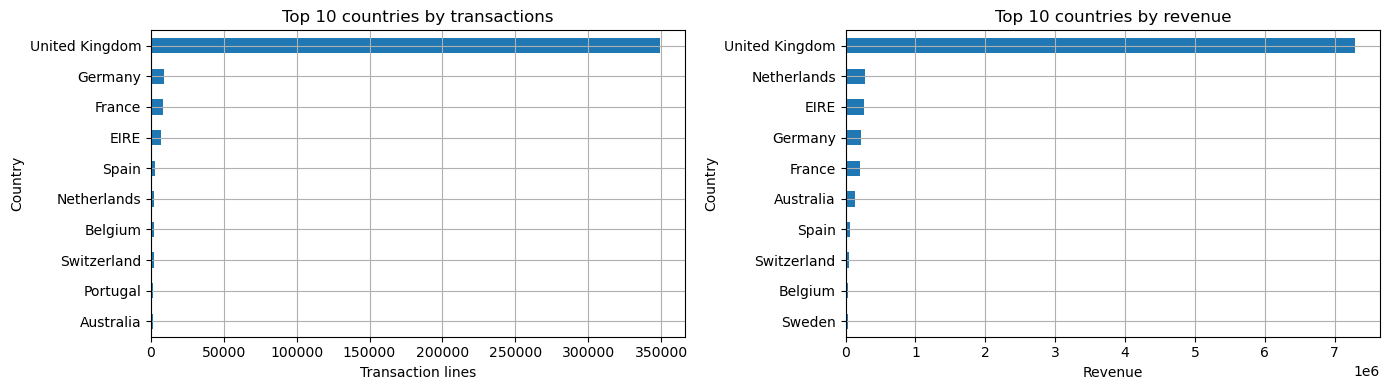

In [29]:
# Simple EDA charts for the business context
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

top_countries_tx = df_clean["Country"].value_counts().head(10).sort_values()
top_countries_tx.plot(kind="barh", ax=axes[0])
axes[0].set_title("Top 10 countries by transactions")
axes[0].set_xlabel("Transaction lines")

country_revenue = df_clean.groupby("Country")["TotalAmount"].sum().sort_values(ascending=False).head(10).sort_values()
country_revenue.plot(kind="barh", ax=axes[1])
axes[1].set_title("Top 10 countries by revenue")
axes[1].set_xlabel("Revenue")

plt.tight_layout()
plt.show()

## RFM Feature Engineering

RFM is a common retail segmentation approach:

- **Recency:** days since the customer last purchased. Lower is better.
- **Frequency:** number of unique invoices. Higher is usually better.
- **Monetary:** total spending. Higher is usually better.

The reference date is set to one day after the latest transaction in the dataset, so Recency is measured consistently for all customers.

In [30]:
reference_date = df_clean["InvoiceDate"].max() + pd.Timedelta(days=1)

rfm = df_clean.groupby("CustomerID").agg(
    Recency=("InvoiceDate", lambda x: (reference_date - x.max()).days),
    Frequency=("InvoiceNo", "nunique"),
    Monetary=("TotalAmount", "sum"),
    TotalQuantity=("Quantity", "sum"),
    ProductDiversity=("StockCode", "nunique"),
).reset_index()

rfm["AvgOrderValue"] = rfm["Monetary"] / rfm["Frequency"]

print("Customer-level RFM shape:", rfm.shape)
rfm.head()

Customer-level RFM shape: (4338, 7)


,CustomerID,Recency,Frequency,Monetary,TotalQuantity,ProductDiversity,AvgOrderValue
0,12346,326,1,77183.60,74215,1,77183.600000
1,12347,2,7,4310.00,2458,103,615.714286
2,12348,75,4,1797.24,2341,22,449.310000
3,12349,19,1,1757.55,631,73,1757.550000
4,12350,310,1,334.40,197,17,334.400000


In [31]:
rfm[["Recency", "Frequency", "Monetary", "AvgOrderValue"]].describe().T

,count,mean,std,min,25%,50%,75%,max
Recency,4338.0,92.536422,100.014169,1.00,18.000000,51.00,142.000000,374.00
Frequency,4338.0,4.272015,7.697998,1.00,1.000000,2.00,5.000000,209.00
Monetary,4338.0,2048.688081,8985.230220,3.75,306.482500,668.57,1660.597500,280206.02
AvgOrderValue,4338.0,417.645735,1796.511343,3.45,177.867083,291.94,428.280625,84236.25


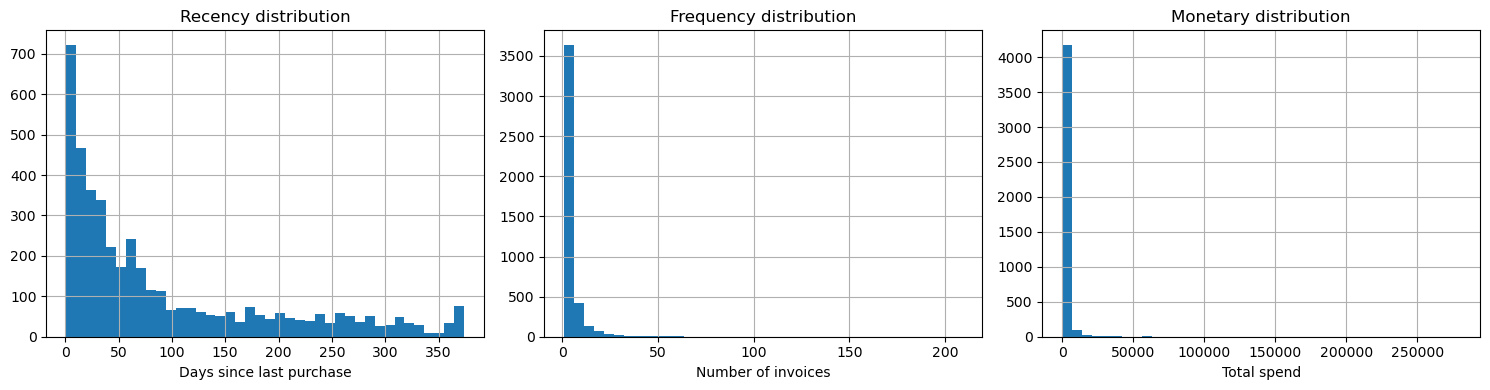

In [32]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(rfm["Recency"], bins=40)
axes[0].set_title("Recency distribution")
axes[0].set_xlabel("Days since last purchase")

axes[1].hist(rfm["Frequency"], bins=40)
axes[1].set_title("Frequency distribution")
axes[1].set_xlabel("Number of invoices")

axes[2].hist(rfm["Monetary"], bins=40)
axes[2].set_title("Monetary distribution")
axes[2].set_xlabel("Total spend")

plt.tight_layout()
plt.show()

# STAGE 3 — Model & Evaluate

We model customer segments using K-Means clustering with RFM features.

Because K-Means is distance-based, the features must be scaled. The raw RFM variables are also highly skewed, especially `Frequency` and `Monetary`, so we apply `log1p` before scaling. This reduces the impact of extreme spenders while keeping the ranking and meaning of the variables.

Validation approach:

1. Split the customer table into train and test sets.
2. Fit the scaler and K-Means only on the train set.
3. Predict cluster labels for the test set.
4. Compare train and test silhouette scores.
5. Choose a value of `k` using both quantitative evidence and business interpretability.

In [33]:
FEATURES = ["Recency", "Frequency", "Monetary"]

rfm_train, rfm_test = train_test_split(
    rfm,
    test_size=0.20,
    random_state=RANDOM_SEED,
)

# log1p handles skew and works even when values are 0; here all values are positive.
X_train_log = np.log1p(rfm_train[FEATURES])
X_test_log = np.log1p(rfm_test[FEATURES])

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_log)
X_test = scaler.transform(X_test_log)

print("Training customers:", len(rfm_train))
print("Test customers:", len(rfm_test))

Training customers: 3470
Test customers: 868


In [34]:
k_values = range(2, 9)
results = []

for k in k_values:
    model = KMeans(n_clusters=k, random_state=RANDOM_SEED, n_init=10)
    train_labels = model.fit_predict(X_train)
    test_labels = model.predict(X_test)

    results.append({
        "k": k,
        "train_inertia": model.inertia_,
        "train_silhouette": silhouette_score(X_train, train_labels),
        "test_silhouette": silhouette_score(X_test, test_labels),
        "train_test_gap": silhouette_score(X_train, train_labels) - silhouette_score(X_test, test_labels),
    })

k_results = pd.DataFrame(results)
k_results.round(4)

,k,train_inertia,train_silhouette,test_silhouette,train_test_gap
0,2,5182.8192,0.4327,0.4331,-0.0004
1,3,3903.7640,0.3344,0.3326,0.0018
2,4,3158.2111,0.3359,0.3368,-0.0008
3,5,2659.7190,0.3139,0.3193,-0.0054
4,6,2304.3622,0.3076,0.3145,-0.0069
5,7,2056.9789,0.3061,0.3135,-0.0074
6,8,1883.8767,0.2987,0.3024,-0.0036


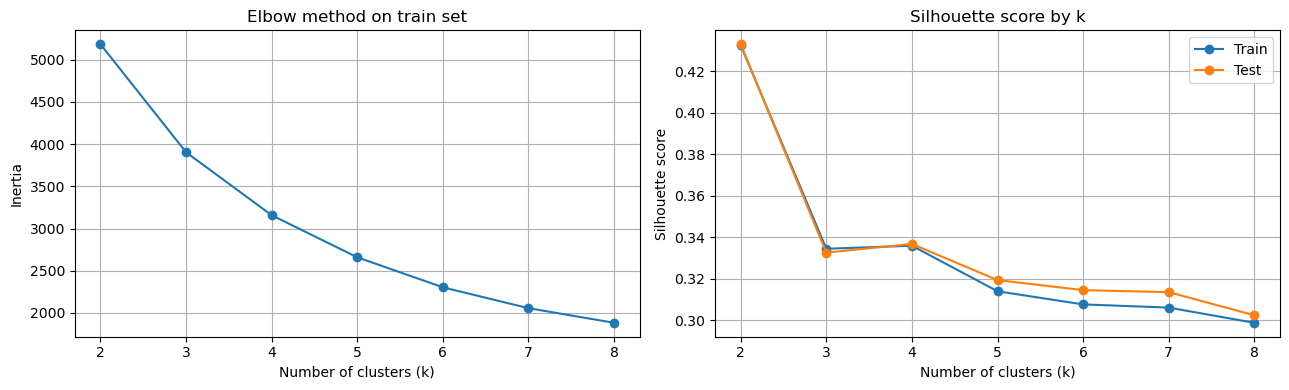

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(k_results["k"], k_results["train_inertia"], marker="o")
axes[0].set_title("Elbow method on train set")
axes[0].set_xlabel("Number of clusters (k)")
axes[0].set_ylabel("Inertia")

axes[1].plot(k_results["k"], k_results["train_silhouette"], marker="o", label="Train")
axes[1].plot(k_results["k"], k_results["test_silhouette"], marker="o", label="Test")
axes[1].set_title("Silhouette score by k")
axes[1].set_xlabel("Number of clusters (k)")
axes[1].set_ylabel("Silhouette score")
axes[1].legend()

plt.tight_layout()
plt.show()

## Choice of k

The highest silhouette score may produce a segmentation that is too broad for marketing. This project needs actionable groups such as high-value customers, at-risk customers and low-engagement customers. For that reason, we choose `k = 5`: it gives more interpretable marketing segments while still showing measurable cluster structure.

We do **not** overclaim the result: if the silhouette is moderate, that is reported as a limitation. In BI, a model should support a decision honestly, not just maximize one metric.

In [36]:
K_FINAL = 5

kmeans = KMeans(n_clusters=K_FINAL, random_state=RANDOM_SEED, n_init=10)
kmeans.fit(X_train)

train_labels = kmeans.labels_
test_labels = kmeans.predict(X_test)

sil_train = silhouette_score(X_train, train_labels)
sil_test = silhouette_score(X_test, test_labels)

print(f"Final k: {K_FINAL}")
print(f"Train silhouette: {sil_train:.4f}")
print(f"Test silhouette : {sil_test:.4f}")
print(f"Train-test gap  : {sil_train - sil_test:+.4f}")

Final k: 5
Train silhouette: 0.3139
Test silhouette : 0.3193
Train-test gap  : -0.0054


In [37]:
# Apply the fitted pipeline to every customer.
# The scaler and K-Means model are not re-fitted here.
X_all = scaler.transform(np.log1p(rfm[FEATURES]))
rfm["Cluster"] = kmeans.predict(X_all)

rfm["Cluster"].value_counts().sort_index()

Cluster
0    1014
1     934
2    1185
3     840
4     365
Name: count, dtype: int64

In [38]:
cluster_profile = rfm.groupby("Cluster").agg(
    Customers=("CustomerID", "count"),
    Recency_mean=("Recency", "mean"),
    Frequency_mean=("Frequency", "mean"),
    Monetary_mean=("Monetary", "mean"),
    AvgOrderValue_mean=("AvgOrderValue", "mean"),
    ProductDiversity_mean=("ProductDiversity", "mean"),
).round(1)

cluster_profile

,Customers,Recency_mean,Frequency_mean,Monetary_mean,AvgOrderValue_mean,ProductDiversity_mean
Cluster,,,,,,
0,1014,105.0,3.1,1454.2,614.1,57.9
1,934,18.4,5.7,2093.3,404.1,95.4
2,1185,210.6,1.2,275.1,246.1,18.9
3,840,28.0,1.6,384.0,264.8,31.5
4,365,12.7,20.0,13175.3,815.3,192.0


## Segment naming

K-Means returns numeric cluster labels such as 0, 1, 2, 3, and 4. These numbers do not have business meaning by themselves. The next cell converts the numeric clusters into marketing names using the cluster profiles.

In [39]:
cluster_means = rfm.groupby("Cluster")[FEATURES].mean()
cluster_z = cluster_means.apply(lambda s: (s - s.mean()) / s.std(ddof=0))

segment_names = {}

# Best segment: recent, frequent, high monetary value.
champion_cluster = (-cluster_z["Recency"] + cluster_z["Frequency"] + cluster_z["Monetary"]).idxmax()
segment_names[champion_cluster] = "High-Value / Champions"

# Weakest segment: old purchases, low frequency, low monetary value.
lost_cluster = (cluster_z["Recency"] - cluster_z["Frequency"] - cluster_z["Monetary"]).idxmax()
segment_names[lost_cluster] = "Low-Engagement / Lost"

remaining = [c for c in cluster_means.index if c not in segment_names]

# At-risk: not very recent, but still has some value/frequency worth trying to recover.
at_risk_cluster = (
    cluster_z.loc[remaining, "Recency"]
    + 0.5 * cluster_z.loc[remaining, "Monetary"]
    + 0.3 * cluster_z.loc[remaining, "Frequency"]
).idxmax()
segment_names[at_risk_cluster] = "At-Risk / Need Attention"

remaining = [c for c in cluster_means.index if c not in segment_names]

# Active regular: recent and reasonably engaged, but not the top VIP segment.
active_cluster = (
    -cluster_z.loc[remaining, "Recency"]
    + 0.5 * cluster_z.loc[remaining, "Frequency"]
    + 0.3 * cluster_z.loc[remaining, "Monetary"]
).idxmax()
segment_names[active_cluster] = "Active Regular"

remaining = [c for c in cluster_means.index if c not in segment_names]
segment_names[remaining[0]] = "Recent Low-Value / Develop"

rfm["Segment"] = rfm["Cluster"].map(segment_names)

segment_names

{4: 'High-Value / Champions',
 2: 'Low-Engagement / Lost',
 0: 'At-Risk / Need Attention',
 1: 'Active Regular',
 3: 'Recent Low-Value / Develop'}

In [40]:
segment_order = [
    "High-Value / Champions",
    "Active Regular",
    "At-Risk / Need Attention",
    "Recent Low-Value / Develop",
    "Low-Engagement / Lost",
]

segment_summary = rfm.groupby("Segment").agg(
    Customers=("CustomerID", "count"),
    AvgRecency=("Recency", "mean"),
    AvgFrequency=("Frequency", "mean"),
    AvgMonetary=("Monetary", "mean"),
    TotalRevenue=("Monetary", "sum"),
    AvgOrderValue=("AvgOrderValue", "mean"),
    AvgProductDiversity=("ProductDiversity", "mean"),
).loc[segment_order].round(1)

segment_summary["CustomerShare_%"] = (segment_summary["Customers"] / segment_summary["Customers"].sum() * 100).round(1)
segment_summary["RevenueShare_%"] = (segment_summary["TotalRevenue"] / segment_summary["TotalRevenue"].sum() * 100).round(1)

segment_summary

,Customers,AvgRecency,AvgFrequency,AvgMonetary,TotalRevenue,AvgOrderValue,AvgProductDiversity,CustomerShare_%,RevenueShare_%
Segment,,,,,,,,,
High-Value / Champions,365,12.7,20.0,13175.3,4808986.6,815.3,192.0,8.4,54.1
Active Regular,934,18.4,5.7,2093.3,1955185.9,404.1,95.4,21.5,22.0
At-Risk / Need Attention,1014,105.0,3.1,1454.2,1474548.1,614.1,57.9,23.4,16.6
Recent Low-Value / Develop,840,28.0,1.6,384.0,322545.1,264.8,31.5,19.4,3.6
Low-Engagement / Lost,1185,210.6,1.2,275.1,325943.2,246.1,18.9,27.3,3.7


In [41]:
# Export customer-level segment assignments for dashboarding or further analysis.
rfm.to_csv("customer_segments_output.csv", index=False)
segment_summary.to_csv("segment_summary_output.csv")
print("Saved customer_segments_output.csv and segment_summary_output.csv")

Saved customer_segments_output.csv and segment_summary_output.csv


# STAGE 4 — Communicate

The following charts are designed for a stakeholder dashboard. They answer three practical questions:

1. How many customers are in each segment?
2. Which segments generate the most revenue?
3. Which segment should receive which marketing action?

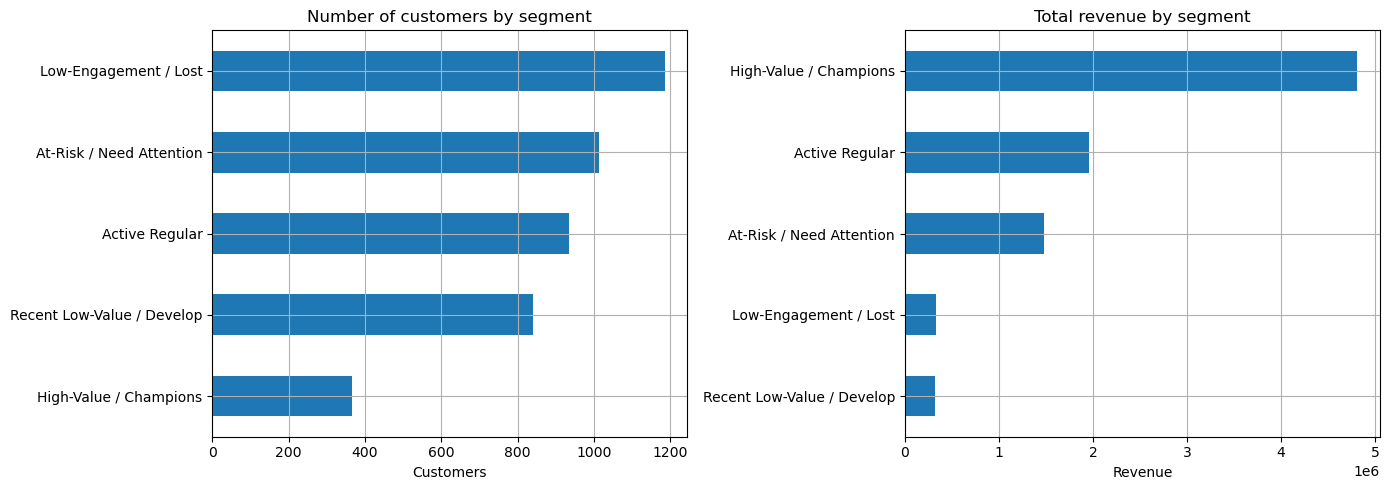

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

segment_summary["Customers"].sort_values().plot(kind="barh", ax=axes[0])
axes[0].set_title("Number of customers by segment")
axes[0].set_xlabel("Customers")
axes[0].set_ylabel("")

segment_summary["TotalRevenue"].sort_values().plot(kind="barh", ax=axes[1])
axes[1].set_title("Total revenue by segment")
axes[1].set_xlabel("Revenue")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

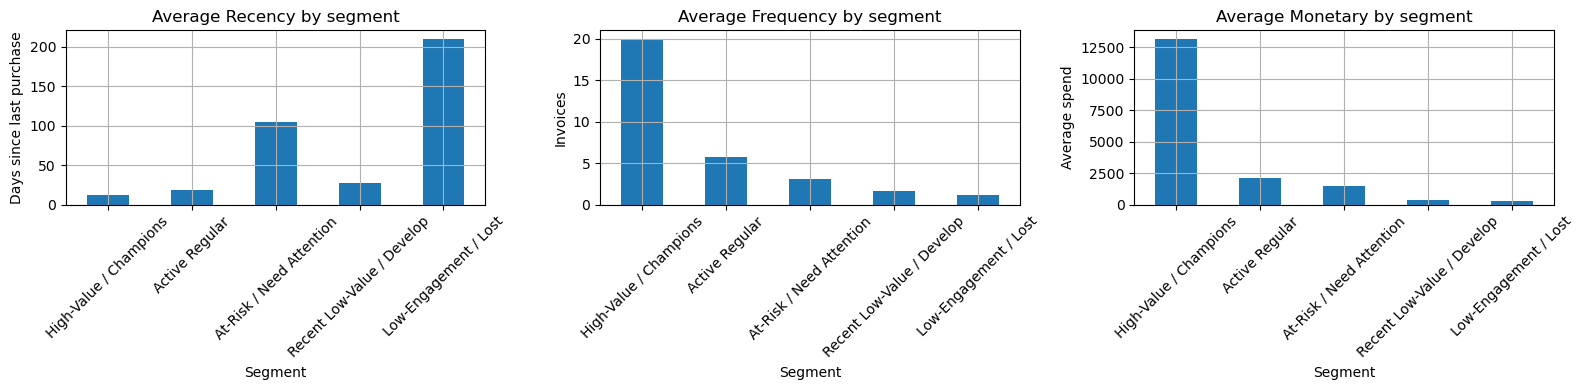

In [43]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

segment_summary["AvgRecency"].plot(kind="bar", ax=axes[0])
axes[0].set_title("Average Recency by segment")
axes[0].set_ylabel("Days since last purchase")
axes[0].tick_params(axis='x', labelrotation=45)

segment_summary["AvgFrequency"].plot(kind="bar", ax=axes[1])
axes[1].set_title("Average Frequency by segment")
axes[1].set_ylabel("Invoices")
axes[1].tick_params(axis='x', labelrotation=45)

segment_summary["AvgMonetary"].plot(kind="bar", ax=axes[2])
axes[2].set_title("Average Monetary by segment")
axes[2].set_ylabel("Average spend")
axes[2].tick_params(axis='x', labelrotation=45)

plt.tight_layout()
plt.show()

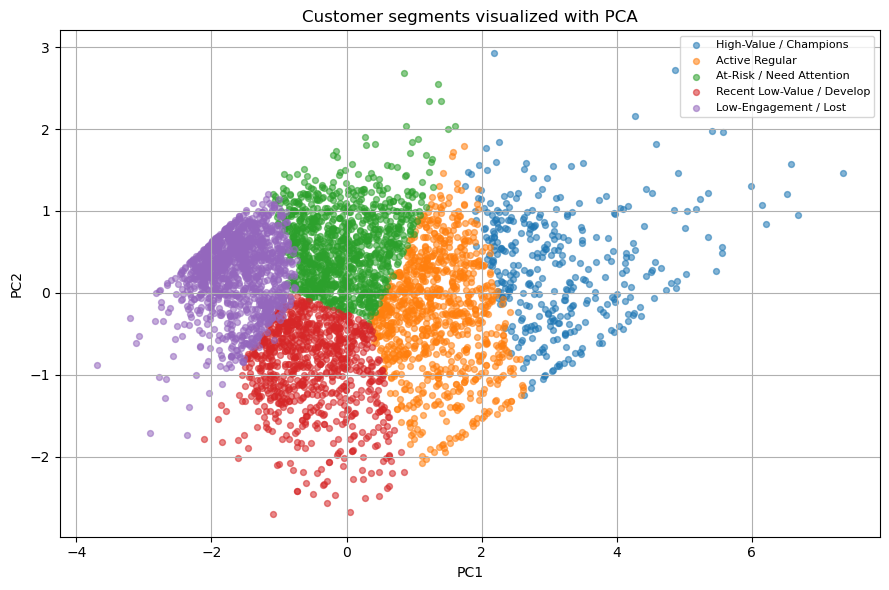

Explained variance by the two PCA components: [0.751 0.187]


In [22]:
# PCA visualization: this is only for communication, not for calculating accuracy.
pca = PCA(n_components=2, random_state=RANDOM_SEED)
Z = pca.fit_transform(X_all)

plot_df = rfm.copy()
plot_df["PC1"] = Z[:, 0]
plot_df["PC2"] = Z[:, 1]

plt.figure(figsize=(9, 6))
for segment in segment_order:
    subset = plot_df[plot_df["Segment"] == segment]
    plt.scatter(subset["PC1"], subset["PC2"], s=18, alpha=0.55, label=segment)

plt.title("Customer segments visualized with PCA")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

print("Explained variance by the two PCA components:", np.round(pca.explained_variance_ratio_, 3))

## Business Recommendation

**Main recommendation:** Use customer segments to personalize marketing instead of sending the same message to every customer.

- **High-Value / Champions:** Protect with loyalty benefits, early access and personalized service. Avoid unnecessary discounts because these customers already buy often and spend more.
- **Active Regular:** Use cross-selling and product recommendations to increase average order value.
- **At-Risk / Need Attention:** Use win-back campaigns, limited-time offers or personalized reminders because these customers still have value but have not purchased recently.
- **Recent Low-Value / Develop:** Use onboarding, bundles and low-cost offers to increase engagement without overspending.
- **Low-Engagement / Lost:** Use only low-cost automated campaigns. Do not spend large paid-marketing budgets on this group unless a test proves it works.

## Self-contained HTML dashboard

The cell below exports a simple HTML dashboard that can be included in the ZIP package or used as dashboard evidence in the presentation.

In [45]:
import base64
import io

SEGMENT_ACTIONS = {
    "High-Value / Champions": "Loyalty rewards, early access, VIP service. Avoid discounts.",
    "Active Regular": "Cross-sell and recommend related products.",
    "At-Risk / Need Attention": "Win-back campaign with limited-time personalized offer.",
    "Recent Low-Value / Develop": "Onboarding and bundle offers to increase engagement.",
    "Low-Engagement / Lost": "Low-cost automated newsletter only; avoid expensive paid campaigns.",
}

def fig_to_base64(fig):
    buffer = io.BytesIO()
    fig.savefig(buffer, format="png", dpi=120, bbox_inches="tight")
    plt.close(fig)
    return base64.b64encode(buffer.getvalue()).decode("utf-8")

# Chart A: customers by segment
fig_a, ax_a = plt.subplots(figsize=(8, 4))
segment_summary["Customers"].plot(kind="bar", ax=ax_a)
ax_a.set_title("Customers by segment")
ax_a.set_ylabel("Customers")
ax_a.tick_params(axis="x", labelrotation=35)
img_a = fig_to_base64(fig_a)

# Chart B: revenue by segment
fig_b, ax_b = plt.subplots(figsize=(8, 4))
segment_summary["TotalRevenue"].plot(kind="bar", ax=ax_b)
ax_b.set_title("Revenue by segment")
ax_b.set_ylabel("Revenue")
ax_b.tick_params(axis="x", labelrotation=35)
img_b = fig_to_base64(fig_b)

rows = ""
for segment in segment_order:
    row = segment_summary.loc[segment]
    rows += f"""
    <tr>
        <td>{segment}</td>
        <td>{row['Customers']:,.0f}</td>
        <td>{row['CustomerShare_%']:.1f}%</td>
        <td>{row['AvgRecency']:.1f}</td>
        <td>{row['AvgFrequency']:.1f}</td>
        <td>£{row['AvgMonetary']:,.0f}</td>
        <td>{row['RevenueShare_%']:.1f}%</td>
        <td>{SEGMENT_ACTIONS[segment]}</td>
    </tr>
    """

html = f"""
<!doctype html>
<html>
<head>
<meta charset='utf-8'>
<title>Online Retail Customer Segmentation Dashboard</title>
<style>
body {{ font-family: Arial, sans-serif; margin: 0; background: #f5f7f8; color: #1b2b2b; }}
header {{ background: #0B6E6E; color: white; padding: 24px 36px; }}
main {{ max-width: 1150px; margin: auto; padding: 24px; }}
.card {{ background: white; border-radius: 12px; padding: 18px; margin: 16px 0; box-shadow: 0 2px 8px rgba(0,0,0,.08); }}
.kpis {{ display: grid; grid-template-columns: repeat(auto-fit, minmax(190px, 1fr)); gap: 14px; }}
.kpi {{ background: white; border-radius: 12px; padding: 18px; box-shadow: 0 2px 8px rgba(0,0,0,.08); }}
.kpi h3 {{ margin: 0; color: #526; font-size: 13px; }}
.kpi p {{ margin: 8px 0 0; font-size: 24px; font-weight: bold; }}
.grid {{ display: grid; grid-template-columns: repeat(auto-fit, minmax(420px, 1fr)); gap: 18px; }}
img {{ max-width: 100%; }}
table {{ width: 100%; border-collapse: collapse; font-size: 13px; }}
th, td {{ border-bottom: 1px solid #ddd; padding: 9px; text-align: left; vertical-align: top; }}
th {{ background: #e8f0f0; }}
</style>
</head>
<body>
<header>
<h1>Online Retail Customer Segmentation Dashboard</h1>
<p>RFM-based K-Means segmentation for targeted marketing decisions.</p>
</header>
<main>
<section class="kpis">
<div class="kpi"><h3>Total customers</h3><p>{len(rfm):,.0f}</p></div>
<div class="kpi"><h3>Total revenue</h3><p>£{rfm['Monetary'].sum():,.0f}</p></div>
<div class="kpi"><h3>Segments</h3><p>{K_FINAL}</p></div>
<div class="kpi"><h3>Test silhouette</h3><p>{sil_test:.3f}</p></div>
</section>
<section class="grid">
<div class="card"><img src="data:image/png;base64,{img_a}" /></div>
<div class="card"><img src="data:image/png;base64,{img_b}" /></div>
</section>
<section class="card">
<h2>Segment profile and recommended action</h2>
<table>
<thead>
<tr>
<th>Segment</th><th>Customers</th><th>Customer share</th><th>Avg Recency</th><th>Avg Frequency</th><th>Avg Monetary</th><th>Revenue share</th><th>Recommended action</th>
</tr>
</thead>
<tbody>{rows}</tbody>
</table>
</section>
</main>
</body>
</html>
"""

with open("online_retail_segmentation_dashboard.html", "w", encoding="utf-8") as f:
    f.write(html)

print("Dashboard saved as online_retail_segmentation_dashboard.html")

Dashboard saved as online_retail_segmentation_dashboard.html


# STAGE 5 — Ethics & Limits

**Privacy:** The dataset does not contain customer names, but `CustomerID` tracks purchasing behavior. If connected to a real CRM system, it would become personal or pseudo-anonymized data. Marketing teams should use it only with proper permissions and opt-in communication rules.

**Bias and representativeness:** The dataset is strongly concentrated in the United Kingdom, so the segments may not transfer directly to other countries or markets without retraining.

**Limitations:**

- The data covers a specific historical period, so customer behavior may have changed.
- K-Means assumes distance-based, roughly compact clusters. Real customers may not follow those mathematical shapes.
- The segmentation is descriptive, not causal. It does not prove that a campaign will increase revenue.
- The `At-Risk` label is inferred from purchasing behavior, not from an observed churn target.
- Removing returns/cancellations improves Monetary calculations, but it also removes potentially useful information about dissatisfied customers.
- The silhouette score is a quality check, not a business outcome. The real test is whether segment-specific campaigns improve retention or revenue.

**Next step:** Run A/B tests for each recommended marketing action and measure conversion rate, repeat purchase rate and revenue uplift by segment.

# Reproducibility Notes

- Random seed is fixed with `RANDOM_SEED = 42`.
- The notebook uses relative paths only.
- The cleaned customer-level segment table is exported as `customer_segments_output.csv`.
- The dashboard is exported as `online_retail_segmentation_dashboard.html`.
- Any AI assistance used to draft, debug or improve the notebook should be disclosed in the project `README.md`, according to the course AI policy.